The below code is for a 3D Plot

Found 85 snapshots:
Rendering 1/85: timestep 0


/tmp/ipykernel_3741359/3661459801.py:68: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(frame_path))


Rendering 2/85: timestep 300
Rendering 3/85: timestep 600
Rendering 4/85: timestep 900
Rendering 5/85: timestep 1200
Rendering 6/85: timestep 1500
Rendering 7/85: timestep 1800
Rendering 8/85: timestep 2100
Rendering 9/85: timestep 2400
Rendering 10/85: timestep 2700
Rendering 11/85: timestep 3000
Rendering 12/85: timestep 3300
Rendering 13/85: timestep 3600
Rendering 14/85: timestep 3900
Rendering 15/85: timestep 4200
Rendering 16/85: timestep 4500
Rendering 17/85: timestep 4800
Rendering 18/85: timestep 5100
Rendering 19/85: timestep 5400
Rendering 20/85: timestep 5700
Rendering 21/85: timestep 6000
Rendering 22/85: timestep 6300
Rendering 23/85: timestep 6600
Rendering 24/85: timestep 6900
Rendering 25/85: timestep 7200
Rendering 26/85: timestep 7500
Rendering 27/85: timestep 7800
Rendering 28/85: timestep 8100
Rendering 29/85: timestep 8400
Rendering 30/85: timestep 8700
Rendering 31/85: timestep 9000
Rendering 32/85: timestep 9300
Rendering 33/85: timestep 9600
Rendering 34/85: ti

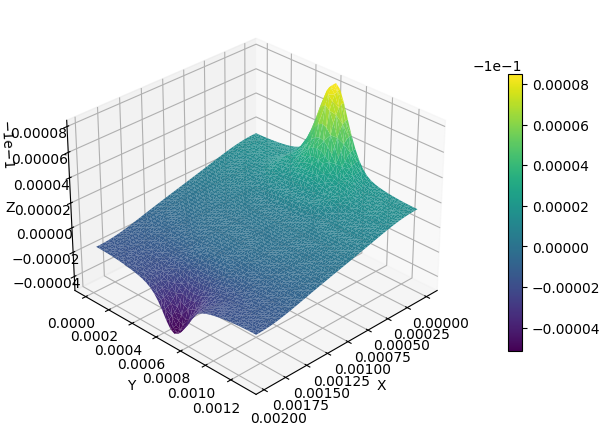

In [3]:
import mfem.ser as mfem
import numpy as np
import matplotlib.pyplot as plt
import imageio
import glob, os

# --- USER SETTINGS ---
result_dir = "outputs/Results/20251104_095151__nsteps=25302__mesh=Mesh_40x60_F00"
mesh_file = os.path.join(result_dir, "pmesh_00000")
pattern = os.path.join(result_dir, "phE_[0-9]*")  # skip gif output
output_gif = os.path.join(result_dir, "phE_animation.gif")

# --- Load mesh once ---
mesh = mfem.Mesh()
mesh.Load(mesh_file)

# Vertex coordinates
vertices = mesh.GetVertexArray()
ar = np.array(vertices)
X, Y = ar[:, 0], ar[:, 1]

# --- Gather snapshot files ---
files = sorted(glob.glob(pattern))
print(f"Found {len(files)} snapshots:")
# for f in files:
#     print("  ", os.path.basename(f))

# --- Setup figure once ---
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
# ax.set_title("Electrolyte Potential (phE)")
ax.view_init(elev=30, azim=45)

# Initialize dummy colorbar
dummy = ax.plot_trisurf(X, Y, np.zeros_like(X), cmap='viridis')
cbar = fig.colorbar(dummy, ax=ax, shrink=0.6, pad=0.1)
dummy.remove()

# --- Create GIF writer ---
with imageio.get_writer(output_gif, mode='I', fps=5) as writer:
    for i, fname in enumerate(files):
        step_str = os.path.basename(fname).split("_")[-1]
        timestep = int(step_str)
        print(f"Rendering {i+1}/{len(files)}: timestep {timestep}")

        # Load grid function
        x = mfem.GridFunction(mesh, fname)
        Z = x.GetDataArray()

        # Auto-compute color scale for this frame
        zmin, zmax = np.min(Z), np.max(Z)

        # Redraw surface and colorbar
        ax.clear()
        surf = ax.plot_trisurf(X, Y, Z, cmap='viridis', vmin=zmin, vmax=zmax, linewidth=0.1)
        ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
        # ax.set_title(f"Electrolyte Potential (phE) — timestep {timestep}")
        ax.set_zlim(zmin, zmax)
        # Update colorbar each frame
        cbar.ax.clear()
        fig.colorbar(surf, cax=cbar.ax)
        # cbar.ax.set_ylabel("Potential")

        # Save frame
        frame_path = "temp_frame.png"
        plt.savefig(frame_path, dpi=100, bbox_inches='tight')
        writer.append_data(imageio.imread(frame_path))

os.remove("temp_frame.png")
print(f"✅ Animation saved to: {output_gif}")

The below code is used for the 2D Contour Plot

Found 85 snapshots:
Rendering 1/85: timestep 0


/tmp/ipykernel_3741359/2556687787.py:72: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(frame_path))


Rendering 2/85: timestep 300
Rendering 3/85: timestep 600
Rendering 4/85: timestep 900
Rendering 5/85: timestep 1200
Rendering 6/85: timestep 1500
Rendering 7/85: timestep 1800
Rendering 8/85: timestep 2100
Rendering 9/85: timestep 2400
Rendering 10/85: timestep 2700
Rendering 11/85: timestep 3000
Rendering 12/85: timestep 3300
Rendering 13/85: timestep 3600
Rendering 14/85: timestep 3900
Rendering 15/85: timestep 4200
Rendering 16/85: timestep 4500
Rendering 17/85: timestep 4800
Rendering 18/85: timestep 5100
Rendering 19/85: timestep 5400
Rendering 20/85: timestep 5700
Rendering 21/85: timestep 6000
Rendering 22/85: timestep 6300
Rendering 23/85: timestep 6600
Rendering 24/85: timestep 6900
Rendering 25/85: timestep 7200
Rendering 26/85: timestep 7500
Rendering 27/85: timestep 7800
Rendering 28/85: timestep 8100
Rendering 29/85: timestep 8400
Rendering 30/85: timestep 8700
Rendering 31/85: timestep 9000
Rendering 32/85: timestep 9300
Rendering 33/85: timestep 9600
Rendering 34/85: ti

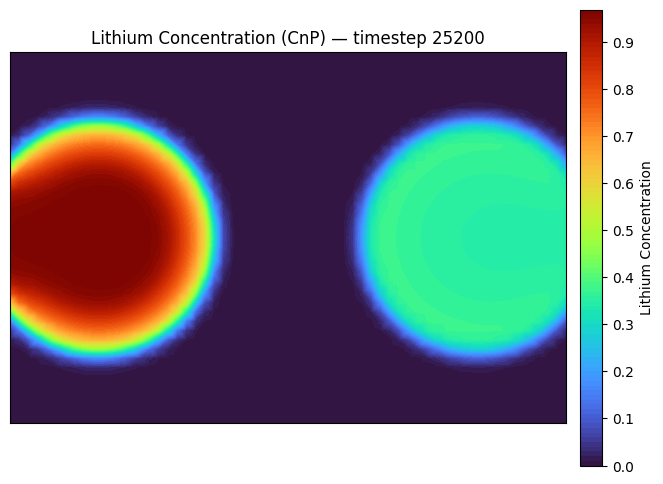

In [4]:
import mfem.ser as mfem
import numpy as np
import matplotlib.pyplot as plt
import imageio
import glob, os
from matplotlib.colors import Normalize

# --- USER SETTINGS ---
result_dir = "outputs/Results/20251104_095151__nsteps=25302__mesh=Mesh_40x60_F00"
mesh_file = os.path.join(result_dir, "pmesh_00000")
pattern = os.path.join(result_dir, "CnP_[0-9]*")
output_gif = os.path.join(result_dir, "CnP_contour_animation.gif")

# --- Load mesh once ---
mesh = mfem.Mesh()
mesh.Load(mesh_file)

# Get vertex coordinates
vertices = mesh.GetVertexArray()
ar = np.array(vertices)
X, Y = ar[:, 0], ar[:, 1]

# --- Gather snapshot files ---
files = sorted(glob.glob(pattern))
files = [f for f in files if os.path.basename(f).split("_")[-1].isdigit()]
print(f"Found {len(files)} snapshots:")
# for f in files:
#     print("  ", os.path.basename(f))

# --- Setup figure ---
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_aspect('equal', adjustable='box')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

# Dummy contour for colorbar
dummy = ax.tricontourf(X, Y, np.zeros_like(X), levels=100, cmap='turbo')
cbar = fig.colorbar(dummy, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Lithium Concentration (CnP)")
ax.clear()

# --- Create GIF writer ---
with imageio.get_writer(output_gif, mode='I', fps=5) as writer:
    for i, fname in enumerate(files):
        step_str = os.path.basename(fname).split("_")[-1]
        timestep = int(step_str)
        print(f"Rendering {i+1}/{len(files)}: timestep {timestep}")

        # ✅ Load properly using MFEM (handles header + data)
        gf = mfem.GridFunction(mesh, fname)
        Z = gf.GetDataArray()

        # Auto-adjust colorbar range for each frame
        zmin, zmax = np.min(Z), np.max(Z)
        norm = Normalize(vmin=zmin, vmax=zmax)

        # Draw filled contour
        ax.clear()
        cntr = ax.tricontourf(X, Y, Z, levels=100, cmap='turbo', norm=norm)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"Lithium Concentration (CnP) — timestep {timestep}")

        # Update colorbar
        cbar.ax.clear()
        fig.colorbar(cntr, cax=cbar.ax)
        cbar.ax.set_ylabel("Lithium Concentration")

        # Save frame
        frame_path = "temp_frame.png"
        plt.savefig(frame_path, dpi=100, bbox_inches='tight')
        writer.append_data(imageio.imread(frame_path))

# Clean up
os.remove("temp_frame.png")
print(f"✅ 2D contour animation saved to: {output_gif}")


To watch video on Mac (local computer):

    1. Download gif file
    2. Run         ffmpeg -i CnP_contour_animation.gif \
                   -vf "scale=ceil(iw/2)*2:ceil(ih/2)*2" \
                   -movflags faststart -pix_fmt yuv420p \
                    CnP_contour_animation.mp4